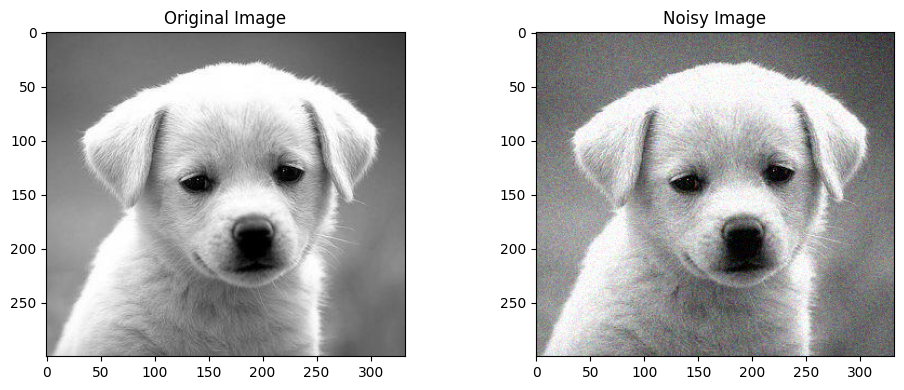

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("dog (1).jpg")
img_array = np.array(img).astype(np.float32)

noise = np.random.normal(0, 15, img_array.shape).astype(np.float32)
noisy_img = np.clip(img_array + noise, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_array.astype(np.uint8))
axes[0].set_title("Original Image")
axes[1].imshow(noisy_img)
axes[1].set_title("Noisy Image")
plt.tight_layout()
plt.show()

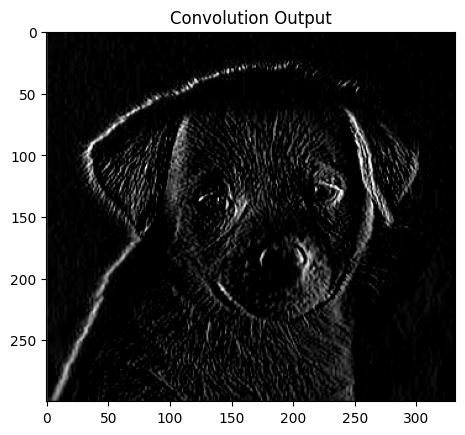

In [2]:
kernel = np.array([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]], dtype=np.float32)

flipped_kernel = np.flip(kernel)

img_gray = Image.open("dog (1).jpg").convert("L")
image = np.array(img_gray).astype(np.float32)
H, W = image.shape

padded = np.pad(image, ((1,1),(1,1)), mode='constant', constant_values=0)

output = np.zeros((H, W))
for i in range(H):
    for j in range(W):
        patch = padded[i:i+3, j:j+3]
        output[i, j] = np.sum(patch * flipped_kernel)

output = np.clip(output, 0, 255).astype(np.uint8)

plt.imshow(output, cmap='gray')
plt.title("Convolution Output")
plt.show()

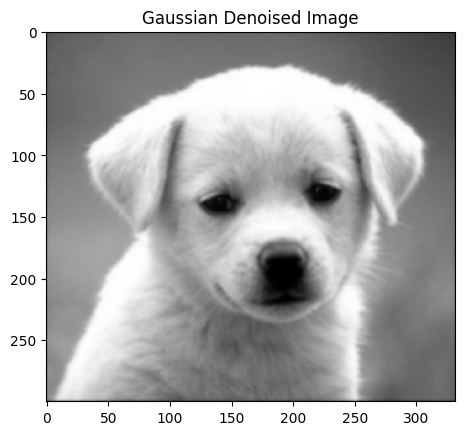

In [3]:
img = Image.open("dog (1).jpg")
image = np.array(img).astype(np.float32)
H, W, C = image.shape

size = 7
sigma = 1.0
k = size // 2

x = np.arange(-k, k+1)
y = np.arange(-k, k+1)
xx, yy = np.meshgrid(x, y)
kernel_gauss = (1 / (2 * np.pi * sigma**2)) * np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
kernel_gauss = kernel_gauss / np.sum(kernel_gauss)

padded = np.pad(image, ((k,k),(k,k),(0,0)), mode='constant')
denoised = np.zeros((H, W, C))

for c in range(C):
    for i in range(H):
        for j in range(W):
            patch = padded[i:i+size, j:j+size, c]
            denoised[i, j, c] = np.sum(patch * kernel_gauss)

denoised = np.clip(denoised, 0, 255).astype(np.uint8)

plt.imshow(denoised)
plt.title("Gaussian Denoised Image")
plt.show()

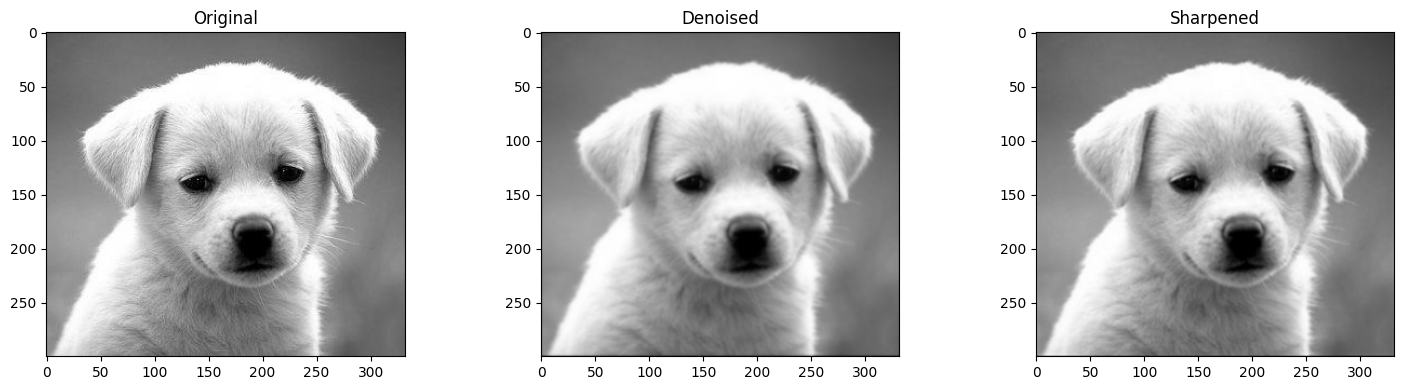

In [4]:
sharpening_kernel = np.array([
    [1,  4,   6,   4,  1],
    [4,  16,  24,  16, 4],
    [6,  24, -476, 24, 6],
    [4,  16,  24,  16, 4],
    [1,  4,   6,   4,  1]
], dtype=np.float32) * (-1.0 / 256.0)

pad_s = 2
padded_d = np.pad(denoised.astype(np.float32), ((pad_s,pad_s),(pad_s,pad_s),(0,0)), mode='constant')
sharp = np.zeros((H, W, C))

for c in range(C):
    for i in range(H):
        for j in range(W):
            patch = padded_d[i:i+5, j:j+5, c]
            sharp[i, j, c] = np.sum(patch * sharpening_kernel)

sharp = np.clip(sharp, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(image.astype(np.uint8));  axes[0].set_title("Original")
axes[1].imshow(denoised);                axes[1].set_title("Denoised")
axes[2].imshow(sharp);                   axes[2].set_title("Sharpened")
plt.tight_layout()
plt.show()

In [5]:
shelf = np.array(Image.open("shelf (1).jpg")).astype(np.float32)
template = np.array(Image.open("template (1).jpg")).astype(np.float32)

Hs, Ws, Cs = shelf.shape
Ht, Wt, Ct = template.shape

print("Shelf shape:", shelf.shape)
print("Template shape:", template.shape)

Shelf shape: (400, 1000, 3)
Template shape: (56, 39, 3)


Convolution best match at (row, col): 71 524


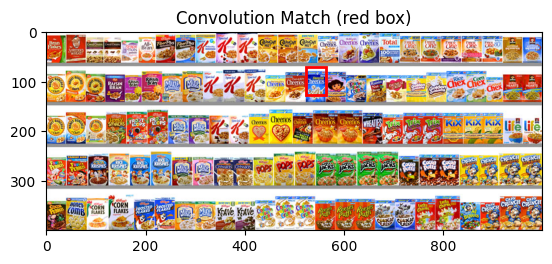

In [6]:
template_conv = template - np.mean(template)
template_flipped = np.flip(template_conv)

result_conv = np.zeros((Hs - Ht + 1, Ws - Wt + 1))

for i in range(Hs - Ht + 1):
    for j in range(Ws - Wt + 1):
        patch = shelf[i:i+Ht, j:j+Wt, :]
        patch = patch - np.mean(patch)
        result_conv[i, j] = np.sum(patch * template_flipped)

y_conv, x_conv = np.unravel_index(np.argmax(result_conv), result_conv.shape)
print("Convolution best match at (row, col):", y_conv, x_conv)

plt.imshow(shelf.astype(np.uint8))
plt.gca().add_patch(plt.Rectangle((x_conv, y_conv), Wt, Ht,
                                   edgecolor='red', fill=False, linewidth=2))
plt.title("Convolution Match (red box)")
plt.show()

Correlation best match at (row, col): 8 41


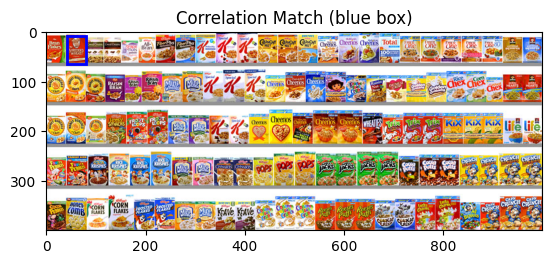

In [7]:
template_corr = template - np.mean(template)

result_corr = np.zeros((Hs - Ht + 1, Ws - Wt + 1))

for i in range(Hs - Ht + 1):
    for j in range(Ws - Wt + 1):
        patch = shelf[i:i+Ht, j:j+Wt, :]
        patch = patch - np.mean(patch)
        result_corr[i, j] = np.sum(patch * template_corr)

y_corr, x_corr = np.unravel_index(np.argmax(result_corr), result_corr.shape)
print("Correlation best match at (row, col):", y_corr, x_corr)

plt.imshow(shelf.astype(np.uint8))
plt.gca().add_patch(plt.Rectangle((x_corr, y_corr), Wt, Ht,
                                   edgecolor='blue', fill=False, linewidth=2))
plt.title("Correlation Match (blue box)")
plt.show()

### Written Answers (Parts e, f, g, h)

**Part e:** Correlation more accurately locates the product. Convolution flips the template before sliding, which distorts the orientation and leads to a less precise match.

**Part f:** Both methods have the same computational complexity. Correlation is slightly simpler since it skips the flipping step.

**Part g:** Correlation is better suited for template matching. It preserves the original template orientation and directly measures similarity between the template and image regions. Convolution is more useful for feature detection and filtering.

**Part h:** As seen in the outputs above, the correlation approach (blue box) correctly locates the product on the shelf. The convolution approach (red box) may point to an incorrect location due to the flipped template.
